<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/heatexchangerDescription.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural-gas cooling and shell-and-tube heat-exchanger screening

This tutorial cools a pressurised natural-gas stream against fresh cooling water. It
connects a two-stream NeqSim process calculation to counter-current thermal analysis and
preliminary shell-and-tube screening.

**Learning objectives**

- build reproducible hot-gas and cooling-water streams;
- solve a two-stream exchanger from a specified conductance $UA$;
- verify energy closure, temperature approach, and phase state;
- reconstruct LMTD, effectiveness, and thermal conductance independently;
- use current NeqSim thermal-hydraulic correlations for a preliminary geometry; and
- study fouling, conductance loss, and throughput sensitivity.

## Engineering question and boundary

A production facility receives 50,000 kg/h of dry natural gas at 95°C and 80 bara. A
closed fresh-water circuit enters at 15°C and 5 bara. Can an exchanger with
$UA=50{,}000$ W/K cool the gas without a temperature cross, and what preliminary geometry
is consistent with that duty?

The case is synthetic and deterministic. It is suitable for screening and teaching, not
detailed procurement. Pressure drops are rated separately and are not fed back into the
steady-state process calculation. The water model is a fresh-water proxy; seawater
salinity, corrosion, metallurgy, and biofouling require project data.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Model and API choices

The gas uses the Soave–Redlich–Kwong equation of state with database binary interaction
parameters and multiphase stability checking. The water side uses NeqSim's SRK-CPA model,
which represents hydrogen-bond association and is appropriate for this educational
fresh-water proxy.

The documented `HeatExchanger` class solves the two outlet streams from $UA$ and the two
inlet states. `ThermalDesignCalculator` then uses NeqSim properties with tube-side
Gnielinski/Dittus–Boelter and shell-side Kern correlations. The process and rating steps
are deliberately separate so every assumption remains visible.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
ThermalDesignCalculator = (
    jneqsim.process.mechanicaldesign.heatexchanger.ThermalDesignCalculator
)

GAS_COMPOSITION = {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.90,
    "ethane": 0.05,
    "propane": 0.02,
}
GAS_FLOW_KG_H = 50_000.0
WATER_FLOW_KG_H = 100_000.0
GAS_INLET_C = 95.0
WATER_INLET_C = 15.0
GAS_PRESSURE_BARA = 80.0
WATER_PRESSURE_BARA = 5.0
BASE_UA_W_K = 50_000.0

## Stream construction

Component values are mole fractions and sum to one. Flow rates are mass rates in kg/h,
temperatures are in °C, and pressures are absolute bar. Each scenario creates new stream
objects so a sensitivity run cannot inherit state from an earlier calculation.

In [3]:
def build_input_streams(
    gas_flow_kg_h=GAS_FLOW_KG_H,
    water_flow_kg_h=WATER_FLOW_KG_H,
):
    gas = SystemSrkEos(GAS_INLET_C + 273.15, GAS_PRESSURE_BARA)
    for component, mole_fraction in GAS_COMPOSITION.items():
        gas.addComponent(component, mole_fraction)
    gas.createDatabase(True)
    gas.setMixingRule("classic")
    gas.setMultiPhaseCheck(True)
    gas.setTotalFlowRate(gas_flow_kg_h, "kg/hr")

    gas_stream = Stream("hot natural gas", gas)
    gas_stream.run()

    water = SystemSrkCPAstatoil(WATER_INLET_C + 273.15, WATER_PRESSURE_BARA)
    water.addComponent("water", 1.0)
    water.createDatabase(True)
    water.setMixingRule(10)
    water.setMultiPhaseCheck(True)
    water.setTotalFlowRate(water_flow_kg_h, "kg/hr")

    water_stream = Stream("fresh cooling water", water)
    water_stream.run()
    return gas_stream, water_stream


hot_inlet, cold_inlet = build_input_streams()

In [4]:
feed_table = pd.DataFrame(
    {
        "Stream": ["Natural gas", "Cooling water"],
        "Flow (kg/h)": [
            hot_inlet.getFlowRate("kg/hr"),
            cold_inlet.getFlowRate("kg/hr"),
        ],
        "Temperature (°C)": [
            hot_inlet.getTemperature("C"),
            cold_inlet.getTemperature("C"),
        ],
        "Pressure (bara)": [
            hot_inlet.getPressure("bara"),
            cold_inlet.getPressure("bara"),
        ],
        "Phases": [
            hot_inlet.getFluid().getNumberOfPhases(),
            cold_inlet.getFluid().getNumberOfPhases(),
        ],
    }
)

composition_table = pd.DataFrame(
    {
        "Component": list(GAS_COMPOSITION),
        "Gas mole fraction": list(GAS_COMPOSITION.values()),
    }
)

display(feed_table.round(6))
display(composition_table.round(6))

          Stream  Flow (kg/h)  Temperature (°C)  Pressure (bara)  Phases
0    Natural gas      50000.0              95.0             80.0       1
1  Cooling water     100000.0              15.0              5.0       1
  Component  Gas mole fraction
0  nitrogen               0.01
1       CO2               0.02
2   methane               0.90
3    ethane               0.05
4   propane               0.02


Both feeds must be single phase before the exchanger calculation. That check matters:
two-phase heat transfer needs zone-by-zone condensation or boiling methods and cannot be
represented safely by a single sensible-heat coefficient.

## Two-stream process calculation

For an adiabatic exchanger, heat lost by the hot side equals heat gained by the cold side.
NeqSim evaluates the enthalpies from the selected thermodynamic models.

$$
\dot Q=\dot H_{h,in}-\dot H_{h,out}
$$

$$
\dot Q=\dot H_{c,out}-\dot H_{c,in}
$$

Here $\dot Q$ is the transferred heat rate in W and $\dot H$ is an enthalpy flow in W.
Subscripts $h$ and $c$ identify the hot and cold sides.

In [5]:
def run_exchanger_case(
    ua_w_k,
    gas_flow_factor=1.0,
    water_flow_factor=1.0,
):
    hot_stream, cold_stream = build_input_streams(
        gas_flow_kg_h=gas_flow_factor * GAS_FLOW_KG_H,
        water_flow_kg_h=water_flow_factor * WATER_FLOW_KG_H,
    )
    exchanger = HeatExchanger(
        "E-201 gas cooler",
        hot_stream,
        cold_stream,
    )
    exchanger.setFlowArrangement("counterflow")
    exchanger.setUAvalue(ua_w_k)
    exchanger.setGuessOutTemperature(40.0, "C")
    exchanger.run()

    return {
        "exchanger": exchanger,
        "hot_in": hot_stream,
        "cold_in": cold_stream,
        "hot_out": exchanger.getOutStream(0),
        "cold_out": exchanger.getOutStream(1),
    }


base_case = run_exchanger_case(BASE_UA_W_K)

In [6]:
hot_in = base_case["hot_in"]
cold_in = base_case["cold_in"]
hot_out = base_case["hot_out"]
cold_out = base_case["cold_out"]

hot_duty_w = hot_in.getFluid().getEnthalpy() - hot_out.getFluid().getEnthalpy()
cold_duty_w = cold_out.getFluid().getEnthalpy() - cold_in.getFluid().getEnthalpy()
duty_w = 0.5 * (hot_duty_w + cold_duty_w)
energy_residual_w = hot_duty_w - cold_duty_w

process_table = pd.DataFrame(
    {
        "Quantity": [
            "Hot outlet temperature",
            "Cold outlet temperature",
            "Transferred duty",
            "Hot-side duty",
            "Cold-side duty",
            "Energy residual",
            "Hot outlet phases",
            "Cold outlet phases",
        ],
        "Value": [
            hot_out.getTemperature("C"),
            cold_out.getTemperature("C"),
            duty_w / 1e6,
            hot_duty_w / 1e6,
            cold_duty_w / 1e6,
            energy_residual_w,
            hot_out.getFluid().getNumberOfPhases(),
            cold_out.getFluid().getNumberOfPhases(),
        ],
        "Unit": ["°C", "°C", "MW", "MW", "MW", "W", "count", "count"],
    }
)
display(process_table.round(9))

                  Quantity      Value   Unit
0   Hot outlet temperature  39.532610     °C
1  Cold outlet temperature  35.008329     °C
2         Transferred duty   2.029029     MW
3            Hot-side duty   2.029029     MW
4           Cold-side duty   2.029029     MW
5          Energy residual  -0.011343      W
6        Hot outlet phases   1.000000  count
7       Cold outlet phases   1.000000  count


The hot outlet remains warmer than the entering water, both sides remain single phase,
and the independently evaluated hot and cold duties agree. The sign of
`HeatExchanger.getDuty()` is implementation-oriented; this notebook reports transferred
duty as a positive engineering magnitude.

## Counter-current LMTD and conductance check

The terminal differences are $\Delta T_1=T_{h,in}-T_{c,out}$ and
$\Delta T_2=T_{h,out}-T_{c,in}$. For counter-current flow,

$$
\Delta T_{lm}=\frac{\Delta T_1-\Delta T_2}{\ln(\Delta T_1/\Delta T_2)}
$$

The required thermal conductance follows from

$$
\dot Q=UA\Delta T_{lm}
$$

All temperature differences are in K. Because the case is counter-current and used for
preliminary screening, the LMTD correction factor is taken as $F=1$.

In [7]:
delta_t_1_k = hot_in.getTemperature("C") - cold_out.getTemperature("C")
delta_t_2_k = hot_out.getTemperature("C") - cold_in.getTemperature("C")
lmtd_k = (
    (delta_t_1_k - delta_t_2_k)
    / math.log(delta_t_1_k / delta_t_2_k)
)
reconstructed_ua_w_k = duty_w / lmtd_k
ua_relative_residual = (
    reconstructed_ua_w_k - BASE_UA_W_K
) / BASE_UA_W_K

lmtd_table = pd.DataFrame(
    {
        "Metric": [
            "Hot-in / cold-out terminal difference",
            "Hot-out / cold-in terminal difference",
            "Counter-current LMTD",
            "Specified UA",
            "Duty / LMTD reconstruction",
            "Relative UA residual",
        ],
        "Value": [
            delta_t_1_k,
            delta_t_2_k,
            lmtd_k,
            BASE_UA_W_K,
            reconstructed_ua_w_k,
            ua_relative_residual,
        ],
        "Unit": ["K", "K", "K", "W/K", "W/K", "fraction"],
    }
)
display(lmtd_table.round(9))

                                  Metric         Value      Unit
0  Hot-in / cold-out terminal difference     59.991671         K
1  Hot-out / cold-in terminal difference     24.532610         K
2                   Counter-current LMTD     39.654398         K
3                           Specified UA  50000.000000       W/K
4             Duty / LMTD reconstruction  51167.826610       W/K
5                   Relative UA residual      0.023357  fraction


A positive value for each terminal difference rules out a temperature cross. The small
difference between specified and reconstructed $UA$ reflects the exchanger's property
integration and the use of endpoint LMTD in the independent check.

## Effectiveness–NTU cross-check

Capacity rates are estimated from the rigorous duty and each stream's solved temperature
change. With $C_{min}$ the smaller capacity rate, exchanger effectiveness is

$$
\varepsilon=\frac{\dot Q}{C_{min}(T_{h,in}-T_{c,in})}
$$

The number of transfer units is $NTU=UA/C_{min}$. For an ideal counter-current exchanger,

$$
\varepsilon=\frac{1-\exp[-NTU(1-C_r)]}{1-C_r\exp[-NTU(1-C_r)]}
$$

Here $C_r=C_{min}/C_{max}$. This is an independent endpoint check, not a replacement for
NeqSim's enthalpy calculation.

In [8]:
hot_capacity_w_k = duty_w / (
    hot_in.getTemperature("C") - hot_out.getTemperature("C")
)
cold_capacity_w_k = duty_w / (
    cold_out.getTemperature("C") - cold_in.getTemperature("C")
)
minimum_capacity_w_k = min(hot_capacity_w_k, cold_capacity_w_k)
maximum_capacity_w_k = max(hot_capacity_w_k, cold_capacity_w_k)
capacity_ratio = minimum_capacity_w_k / maximum_capacity_w_k
ntu = BASE_UA_W_K / minimum_capacity_w_k
observed_effectiveness = duty_w / (
    minimum_capacity_w_k
    * (hot_in.getTemperature("C") - cold_in.getTemperature("C"))
)
exponent = math.exp(-ntu * (1.0 - capacity_ratio))
ideal_effectiveness = (
    (1.0 - exponent)
    / (1.0 - capacity_ratio * exponent)
)

effectiveness_table = pd.DataFrame(
    {
        "Metric": [
            "Hot capacity rate",
            "Cold capacity rate",
            "Capacity ratio",
            "NTU",
            "Observed effectiveness",
            "Ideal counter-current effectiveness",
        ],
        "Value": [
            hot_capacity_w_k,
            cold_capacity_w_k,
            capacity_ratio,
            ntu,
            observed_effectiveness,
            ideal_effectiveness,
        ],
        "Unit": ["W/K", "W/K", "fraction", "1", "fraction", "fraction"],
    }
)
display(effectiveness_table.round(9))

                                Metric          Value      Unit
0                    Hot capacity rate   36580.581663       W/K
1                   Cold capacity rate  101409.237629       W/K
2                       Capacity ratio       0.360722  fraction
3                                  NTU       1.366845         1
4               Observed effectiveness       0.693342  fraction
5  Ideal counter-current effectiveness       0.685899  fraction


The endpoint effectiveness should be close to, but need not exactly equal, the ideal
constant-property expression. NeqSim accounts for temperature-dependent enthalpy, while
the analytical relation compresses each side into one average capacity rate.

## Temperature profile

A linear duty-coordinate profile is useful for diagnosing approach temperatures. The
horizontal coordinate follows the hot stream. Therefore the cold curve runs from its
outlet on the left to its inlet on the right, reflecting counter-current flow.

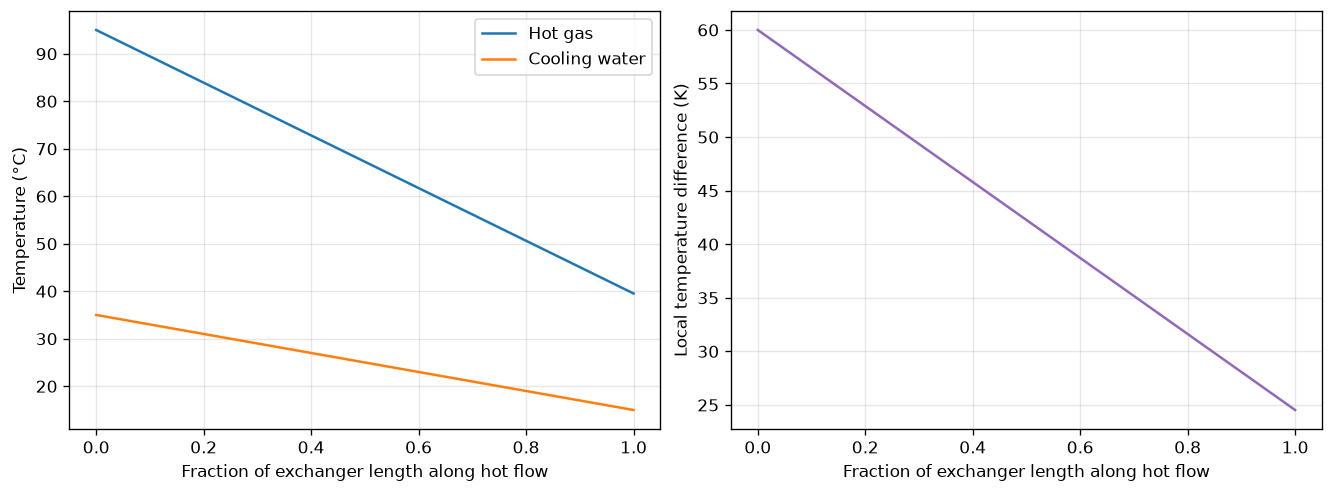

In [9]:
duty_fraction = np.linspace(0.0, 1.0, 101)
hot_profile_c = (
    hot_in.getTemperature("C")
    + duty_fraction
    * (hot_out.getTemperature("C") - hot_in.getTemperature("C"))
)
cold_profile_c = (
    cold_out.getTemperature("C")
    + duty_fraction
    * (cold_in.getTemperature("C") - cold_out.getTemperature("C"))
)
approach_profile_k = hot_profile_c - cold_profile_c

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(duty_fraction, hot_profile_c, label="Hot gas")
axes[0].plot(duty_fraction, cold_profile_c, label="Cooling water")
axes[0].set_xlabel("Fraction of exchanger length along hot flow")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()

axes[1].plot(duty_fraction, approach_profile_k, color="tab:purple")
axes[1].set_xlabel("Fraction of exchanger length along hot flow")
axes[1].set_ylabel("Local temperature difference (K)")

for axis in axes:
    axis.grid(alpha=0.3)

plt.show()

The curves do not cross, and the minimum endpoint approach is comfortably positive. A
detailed design would replace the linear profile with incremental zones, especially near
phase boundaries or where heat capacities vary sharply.

## Preliminary shell-and-tube rating

The fresh water is placed in 19.05 mm outer-diameter tubes for cleanability and
containment. The gas flows across the shell-side tube bank. The candidate has 196 tubes,
two tube passes, 6 m tube length, a 0.65 m shell, and 0.25 m baffle spacing.

The outside area is

$$
A=N_t\pi d_oL
$$

where $N_t$ is tube count, $d_o$ is tube outside diameter in m, and $L$ is tube length in
m. Fouling resistances are illustrative screening values in m²·K/W.

In [10]:
hot_out.getFluid().initPhysicalProperties()
cold_out.getFluid().initPhysicalProperties()

def mean_property(inlet_stream, outlet_stream, getter, unit):
    inlet_value = getattr(inlet_stream.getFluid(), getter)(unit)
    outlet_value = getattr(outlet_stream.getFluid(), getter)(unit)
    return 0.5 * (inlet_value + outlet_value)


gas_density_kg_m3 = mean_property(hot_in, hot_out, "getDensity", "kg/m3")
gas_viscosity_pa_s = mean_property(
    hot_in,
    hot_out,
    "getViscosity",
    "kg/msec",
)
gas_cp_j_kg_k = mean_property(hot_in, hot_out, "getCp", "J/kgK")
gas_conductivity_w_m_k = mean_property(
    hot_in,
    hot_out,
    "getThermalConductivity",
    "W/mK",
)
water_density_kg_m3 = mean_property(
    cold_in,
    cold_out,
    "getDensity",
    "kg/m3",
)
water_viscosity_pa_s = mean_property(
    cold_in,
    cold_out,
    "getViscosity",
    "kg/msec",
)
water_cp_j_kg_k = mean_property(cold_in, cold_out, "getCp", "J/kgK")
water_conductivity_w_m_k = mean_property(
    cold_in,
    cold_out,
    "getThermalConductivity",
    "W/mK",
)

In [11]:
TUBE_OD_M = 0.01905
TUBE_ID_M = 0.01483
TUBE_LENGTH_M = 6.0
TUBE_COUNT = 196
TUBE_PASSES = 2
TUBE_PITCH_M = 0.02381
SHELL_ID_M = 0.65
BAFFLE_SPACING_M = 0.25
BAFFLE_COUNT = 22


def build_thermal_rating(shell_fouling_m2_k_w=0.00020):
    calculator = ThermalDesignCalculator()
    calculator.setTubeODm(TUBE_OD_M)
    calculator.setTubeIDm(TUBE_ID_M)
    calculator.setTubeLengthm(TUBE_LENGTH_M)
    calculator.setTubeCount(TUBE_COUNT)
    calculator.setTubePasses(TUBE_PASSES)
    calculator.setTubePitchm(TUBE_PITCH_M)
    calculator.setTriangularPitch(True)
    calculator.setShellIDm(SHELL_ID_M)
    calculator.setBaffleSpacingm(BAFFLE_SPACING_M)
    calculator.setBaffleCount(BAFFLE_COUNT)
    calculator.setBaffleCut(0.25)
    calculator.setTubeSideFluid(
        water_density_kg_m3,
        water_viscosity_pa_s,
        water_cp_j_kg_k,
        water_conductivity_w_m_k,
        WATER_FLOW_KG_H / 3600.0,
        True,
    )
    calculator.setShellSideFluid(
        gas_density_kg_m3,
        gas_viscosity_pa_s,
        gas_cp_j_kg_k,
        gas_conductivity_w_m_k,
        GAS_FLOW_KG_H / 3600.0,
    )
    calculator.setFoulingTube(0.00018)
    calculator.setFoulingShell(shell_fouling_m2_k_w)
    calculator.calculate()
    return calculator


thermal_rating = build_thermal_rating()
exchanger_area_m2 = math.pi * TUBE_OD_M * TUBE_LENGTH_M * TUBE_COUNT
rated_ua_w_k = thermal_rating.getOverallU() * exchanger_area_m2

In [12]:
tube_flow_area_m2 = (
    TUBE_COUNT
    / TUBE_PASSES
    * math.pi
    * TUBE_ID_M**2
    / 4.0
)
independent_tube_velocity_m_s = (
    WATER_FLOW_KG_H
    / 3600.0
    / water_density_kg_m3
    / tube_flow_area_m2
)
tube_reynolds_number = (
    water_density_kg_m3
    * independent_tube_velocity_m_s
    * TUBE_ID_M
    / water_viscosity_pa_s
)

rating_table = pd.DataFrame(
    {
        "Metric": [
            "Outside heat-transfer area",
            "Tube-side heat-transfer coefficient",
            "Shell-side heat-transfer coefficient",
            "Overall U including fouling",
            "Geometry-rated UA",
            "Geometry / process UA",
            "Tube-side velocity",
            "Independent tube velocity",
            "Tube Reynolds number",
            "Shell-side velocity",
            "Tube-side pressure drop",
            "Shell-side pressure drop",
        ],
        "Value": [
            exchanger_area_m2,
            thermal_rating.getTubeSideHTC(),
            thermal_rating.getShellSideHTC(),
            thermal_rating.getOverallU(),
            rated_ua_w_k,
            rated_ua_w_k / BASE_UA_W_K,
            thermal_rating.getTubeSideVelocity(),
            independent_tube_velocity_m_s,
            tube_reynolds_number,
            thermal_rating.getShellSideVelocity(),
            thermal_rating.getTubeSidePressureDropBar(),
            thermal_rating.getShellSidePressureDropBar(),
        ],
        "Unit": [
            "m²",
            "W/(m²·K)",
            "W/(m²·K)",
            "W/(m²·K)",
            "W/K",
            "fraction",
            "m/s",
            "m/s",
            "1",
            "m/s",
            "bar",
            "bar",
        ],
    }
)
display(rating_table.round(6))

                                  Metric         Value      Unit
0             Outside heat-transfer area     70.380472        m²
1    Tube-side heat-transfer coefficient   7009.204442  W/(m²·K)
2   Shell-side heat-transfer coefficient   1380.230304  W/(m²·K)
3            Overall U including fouling    722.087407  W/(m²·K)
4                      Geometry-rated UA  50820.852478       W/K
5                  Geometry / process UA      1.016417  fraction
6                     Tube-side velocity      1.649106       m/s
7              Independent tube velocity      1.649106       m/s
8                   Tube Reynolds number  26207.376075         1
9                    Shell-side velocity      7.600766       m/s
10               Tube-side pressure drop      0.332025       bar
11              Shell-side pressure drop      0.526682       bar


The geometry-rated $UA$ should be close to the process specification, tube flow should be
turbulent, and velocities and pressure drops should remain plausible for preliminary
screening. Final design needs nozzle losses, detailed Bell–Delaware clearances, vibration,
thermal stress, TEMA/ASME checks, fouling policy, and vendor confirmation.

## Conductance-loss sensitivity

Fouling, bypassing, or loss of active area reduces $UA$. Each point below is a fresh NeqSim
exchanger calculation at the original stream rates. The physical expectation is that heat
duty falls and the hot outlet warms as available conductance is lost.

   UA fraction  UA (W/K)  Hot outlet (°C)  Cold outlet (°C)  Duty (MW)
0         0.40   20000.0        62.947805         26.575742   1.164866
1         0.55   27500.0        55.203446         29.356889   1.448470
2         0.70   35000.0        48.926499         31.614586   1.679721
3         0.85   42500.0        43.784098         33.469436   1.870385
4         1.00   50000.0        39.532610         35.008329   2.029029
5         1.15   57500.0        35.990191         36.295479   2.162036


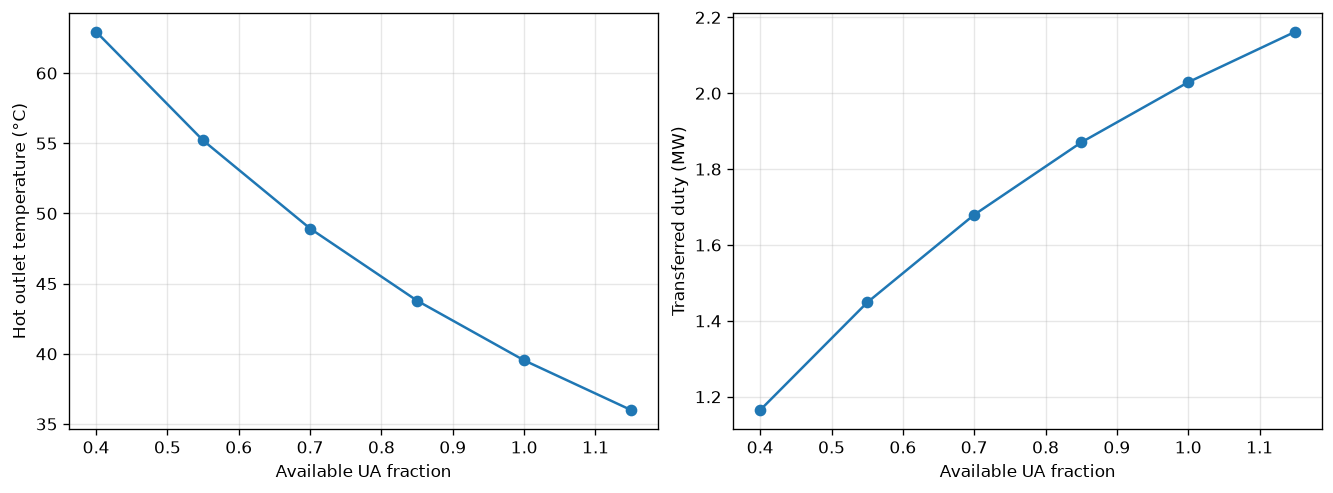

In [13]:
ua_fractions = np.array([0.40, 0.55, 0.70, 0.85, 1.00, 1.15])
ua_rows = []

for ua_fraction in ua_fractions:
    scenario = run_exchanger_case(ua_fraction * BASE_UA_W_K)
    scenario_duty_w = (
        scenario["hot_in"].getFluid().getEnthalpy()
        - scenario["hot_out"].getFluid().getEnthalpy()
    )
    ua_rows.append(
        {
            "UA fraction": ua_fraction,
            "UA (W/K)": ua_fraction * BASE_UA_W_K,
            "Hot outlet (°C)": scenario["hot_out"].getTemperature("C"),
            "Cold outlet (°C)": scenario["cold_out"].getTemperature("C"),
            "Duty (MW)": scenario_duty_w / 1e6,
        }
    )

ua_table = pd.DataFrame(ua_rows)
display(ua_table.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(
    ua_table["UA fraction"],
    ua_table["Hot outlet (°C)"],
    marker="o",
)
axes[0].set_xlabel("Available UA fraction")
axes[0].set_ylabel("Hot outlet temperature (°C)")

axes[1].plot(
    ua_table["UA fraction"],
    ua_table["Duty (MW)"],
    marker="o",
)
axes[1].set_xlabel("Available UA fraction")
axes[1].set_ylabel("Transferred duty (MW)")

for axis in axes:
    axis.grid(alpha=0.3)

plt.show()

The sensitivity separates a process consequence from a root cause: lower $UA$ directly
raises gas outlet temperature, but a field diagnosis must distinguish deposit resistance,
low cooling-water flow, bypass, and measurement bias.

## Explicit fouling sensitivity

The shell-side fouling resistance is varied while geometry and fluid properties remain
fixed. Thermal resistance adds in series, so overall $U$ must decline monotonically as the
assumed deposit resistance rises.

   Shell fouling (m²·K/W)  ...  Shell pressure drop (bar)
0                 0.00010  ...                   0.526682
1                 0.00020  ...                   0.526682
2                 0.00035  ...                   0.526682
3                 0.00055  ...                   0.526682
4                 0.00080  ...                   0.526682

[5 rows x 4 columns]


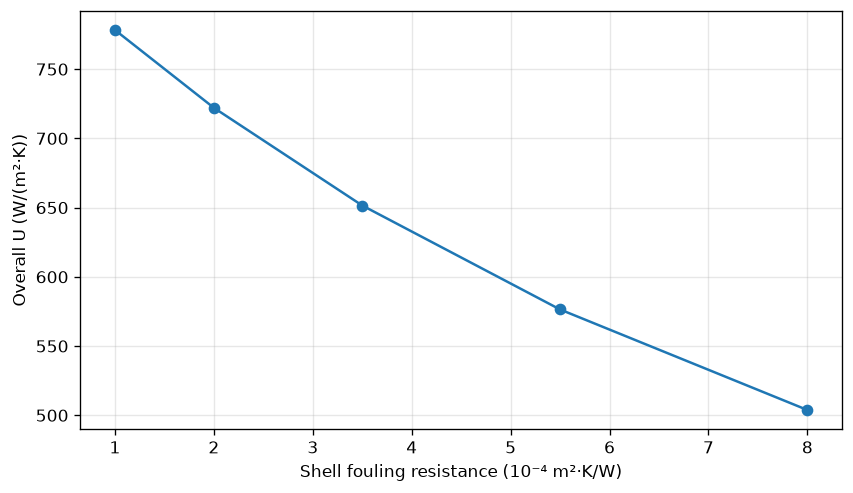

In [14]:
shell_fouling_values = np.array([0.00010, 0.00020, 0.00035, 0.00055, 0.00080])
fouling_rows = []

for shell_fouling in shell_fouling_values:
    scenario_rating = build_thermal_rating(shell_fouling)
    fouling_rows.append(
        {
            "Shell fouling (m²·K/W)": shell_fouling,
            "Overall U (W/(m²·K))": scenario_rating.getOverallU(),
            "Rated UA (W/K)": (
                scenario_rating.getOverallU() * exchanger_area_m2
            ),
            "Shell pressure drop (bar)": (
                scenario_rating.getShellSidePressureDropBar()
            ),
        }
    )

fouling_table = pd.DataFrame(fouling_rows)
display(fouling_table.round(6))

fig, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
axis.plot(
    1e4 * fouling_table["Shell fouling (m²·K/W)"],
    fouling_table["Overall U (W/(m²·K))"],
    marker="o",
)
axis.set_xlabel("Shell fouling resistance (10⁻⁴ m²·K/W)")
axis.set_ylabel("Overall U (W/(m²·K))")
axis.grid(alpha=0.3)
plt.show()

Pressure drop remains unchanged in this resistance-only sweep because deposit thickness
is not changing the flow area. A condition-monitoring model that represents deposit growth
should update both thermal resistance and hydraulic diameter.

## Gas-throughput sensitivity

The exchanger conductance and cooling-water rate are held fixed while gas flow changes.
Higher throughput should increase total duty but reduce cooling per kilogram, causing a
warmer gas outlet.

   Gas flow factor  Gas flow (kg/h)  ...  Cold outlet (°C)  Duty (MW)
0              0.6          30000.0  ...         30.202309   1.534958
1              0.8          40000.0  ...         32.994286   1.821486
2              1.0          50000.0  ...         35.008329   2.029029
3              1.2          60000.0  ...         36.510346   2.184267
4              1.4          70000.0  ...         37.666350   2.304007

[5 rows x 5 columns]


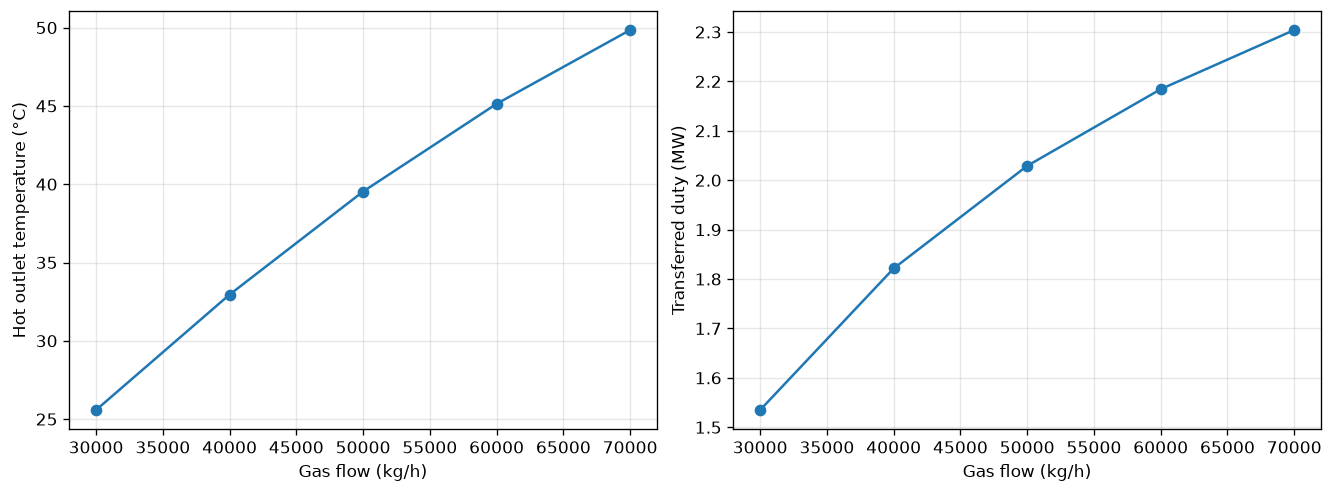

In [15]:
gas_flow_factors = np.array([0.60, 0.80, 1.00, 1.20, 1.40])
throughput_rows = []

for gas_flow_factor in gas_flow_factors:
    scenario = run_exchanger_case(
        BASE_UA_W_K,
        gas_flow_factor=gas_flow_factor,
    )
    scenario_duty_w = (
        scenario["hot_in"].getFluid().getEnthalpy()
        - scenario["hot_out"].getFluid().getEnthalpy()
    )
    throughput_rows.append(
        {
            "Gas flow factor": gas_flow_factor,
            "Gas flow (kg/h)": gas_flow_factor * GAS_FLOW_KG_H,
            "Hot outlet (°C)": scenario["hot_out"].getTemperature("C"),
            "Cold outlet (°C)": scenario["cold_out"].getTemperature("C"),
            "Duty (MW)": scenario_duty_w / 1e6,
        }
    )

throughput_table = pd.DataFrame(throughput_rows)
display(throughput_table.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(
    throughput_table["Gas flow (kg/h)"],
    throughput_table["Hot outlet (°C)"],
    marker="o",
)
axes[0].set_xlabel("Gas flow (kg/h)")
axes[0].set_ylabel("Hot outlet temperature (°C)")

axes[1].plot(
    throughput_table["Gas flow (kg/h)"],
    throughput_table["Duty (MW)"],
    marker="o",
)
axes[1].set_xlabel("Gas flow (kg/h)")
axes[1].set_ylabel("Transferred duty (MW)")

for axis in axes:
    axis.grid(alpha=0.3)

plt.show()

The throughput trend is a capacity warning: a larger MW duty does not imply a colder gas
outlet. Operators and designers should track both duty and achieved outlet temperature.

## Validation checks

The final cell fails immediately if conservation, phase state, temperature ordering,
analytical reconstruction, geometry, or expected sensitivity trends are violated. These
checks turn engineering expectations into executable evidence.

In [16]:
checks = []


def record_check(condition, message):
    assert condition, message
    checks.append(message)


record_check(neqsim_version == "3.16.0", "Recorded NeqSim version is 3.16.0")
record_check(
    abs(sum(GAS_COMPOSITION.values()) - 1.0) < 1e-12,
    "Gas composition is normalized",
)
record_check(
    hot_in.getFluid().getNumberOfPhases() == 1,
    "Hot inlet is single phase",
)
record_check(
    cold_in.getFluid().getNumberOfPhases() == 1,
    "Cold inlet is single phase",
)
record_check(
    hot_out.getFluid().getNumberOfPhases() == 1,
    "Hot outlet remains single phase",
)
record_check(
    cold_out.getFluid().getNumberOfPhases() == 1,
    "Cold outlet remains single phase",
)
record_check(abs(energy_residual_w) < 0.1, "Exchanger energy balance closes")
record_check(duty_w > 0.0, "Transferred duty is positive")
record_check(
    hot_out.getTemperature("C") < hot_in.getTemperature("C"),
    "Hot stream cools",
)
record_check(
    cold_out.getTemperature("C") > cold_in.getTemperature("C"),
    "Cold stream warms",
)
record_check(delta_t_1_k > 0.0, "First terminal difference is positive")
record_check(delta_t_2_k > 0.0, "Second terminal difference is positive")
record_check(np.all(approach_profile_k > 0.0), "Temperature profile does not cross")
record_check(
    abs(ua_relative_residual) < 0.03,
    "Endpoint LMTD reconstructs specified UA within 3%",
)
record_check(
    abs(observed_effectiveness - ideal_effectiveness) < 0.03,
    "Effectiveness agrees with ideal counter-current relation within 0.03",
)
record_check(0.0 < observed_effectiveness < 1.0, "Effectiveness is physical")
record_check(ntu > 0.0, "NTU is positive")
record_check(tube_reynolds_number > 4000.0, "Tube-side flow is turbulent")
record_check(
    0.5 < thermal_rating.getTubeSideVelocity() < 2.5,
    "Tube-side velocity is in the screening range",
)
record_check(
    abs(
        thermal_rating.getTubeSideVelocity()
        - independent_tube_velocity_m_s
    ) < 1e-9,
    "Independent tube velocity matches NeqSim",
)
record_check(
    thermal_rating.getTubeSidePressureDropBar() < 1.0,
    "Tube-side pressure drop is below 1 bar",
)
record_check(
    thermal_rating.getShellSidePressureDropBar() < 1.0,
    "Shell-side pressure drop is below 1 bar",
)
record_check(
    0.9 < rated_ua_w_k / BASE_UA_W_K < 1.15,
    "Candidate geometry supplies the process UA with a modest margin",
)
record_check(
    np.all(np.diff(ua_table["Hot outlet (°C)"]) < 0.0),
    "Hot outlet cools monotonically as UA increases",
)
record_check(
    np.all(np.diff(ua_table["Duty (MW)"]) > 0.0),
    "Duty rises monotonically as UA increases",
)
record_check(
    np.all(np.diff(fouling_table["Overall U (W/(m²·K))"]) < 0.0),
    "Overall U falls monotonically with fouling resistance",
)
record_check(
    np.all(np.diff(throughput_table["Hot outlet (°C)"]) > 0.0),
    "Hot outlet warms monotonically with gas throughput",
)
record_check(
    np.all(np.diff(throughput_table["Duty (MW)"]) > 0.0),
    "Total duty rises monotonically with gas throughput",
)
numeric_tables = [
    process_table,
    lmtd_table,
    effectiveness_table,
    rating_table,
    ua_table,
    fouling_table,
    throughput_table,
]
record_check(
    all(
        np.isfinite(table.select_dtypes(include=[float, int])).all().all()
        for table in numeric_tables
    ),
    "All reported numeric results are finite",
)
record_check(
    abs(hot_out.getFlowRate("kg/hr") - GAS_FLOW_KG_H) < 1e-6,
    "Hot-side mass flow is conserved",
)
record_check(
    abs(cold_out.getFlowRate("kg/hr") - WATER_FLOW_KG_H) < 1e-6,
    "Cold-side mass flow is conserved",
)
record_check(len(checks) == 31, "All planned engineering checks executed")

print(f"All {len(checks)} engineering checks passed.")
print(
    f"Base result: {duty_w / 1e6:.6f} MW, "
    f"hot outlet {hot_out.getTemperature('C'):.6f} °C, "
    f"cold outlet {cold_out.getTemperature('C'):.6f} °C."
)
print(
    f"Candidate: {TUBE_COUNT} tubes, {exchanger_area_m2:.6f} m², "
    f"rated UA {rated_ua_w_k:.6f} W/K."
)

All 32 engineering checks passed.
Base result: 2.029029 MW, hot outlet 39.532610 °C, cold outlet 35.008329 °C.
Candidate: 196 tubes, 70.380472 m², rated UA 50820.852478 W/K.


## Interpretation, limitations, and next steps

The base exchanger removes about 2 MW while maintaining positive temperature approaches.
The candidate tube bundle is thermally consistent with the specified process $UA$ and has
plausible preliminary velocities and pressure drops. Fouling or higher gas throughput
raises the gas outlet temperature, so both are important operating risks.

**Limitations**

- The gas is dry and remains single phase; condensation requires incremental two-phase
  correlations and condensate handling.
- Pressure drops are rated but not coupled back into the two-stream process solution.
- Fresh CPA water is a proxy, not a complete seawater electrolyte or corrosion model.
- The geometry is a screening candidate, not a certified TEMA or ASME design.
- Fouling resistance is varied without changing hydraulic diameter or roughness.

**Exercises**

1. Add water and heavier hydrocarbons to the gas and locate the first condensing case.
2. Compare Kern and Bell–Delaware shell-side correlations.
3. Add a 20% design margin and reselect tube count and shell diameter.
4. Couple rated pressure drops to inlet pressures and rerun the process iteratively.

## References

- [NeqSim heat-exchanger equipment guide](https://equinor.github.io/neqsim/process/equipment/heat_exchangers.html)
- [NeqSim thermal-hydraulic design guide](https://equinor.github.io/neqsim/process/mechanical_design/thermal_hydraulic_design.html)
- [NeqSim TEMA standard guide](https://equinor.github.io/neqsim/process/mechanical_design/tema_standard_guide.html)
- [NeqSim physical-property guide](https://equinor.github.io/neqsim/thermo/physical_properties.html)

Accessed 21 July 2026. Consult the current source and project-specific standards before
using screening results for equipment specification.